# COSC 3337 - Data Science I
## Exploratory Data Analysis Assignment

#### The goal of this assignment is to:
1. Learn how to pre-process datasets using statistics and visualizations
2. Learn how to interpret computed statistics and visualization to gain an understanding of the dataset
3. Learn properties of the dataset and its characteristics that may lend to understanding of expected results from data analysis
####

#### Dataset - winequality
**Intended Outcome:**
The objective of Assignment 1 is to explore the relationships between different
wine attributes and their potential impact on quality. You will gain practical
experience in data visualization, exploration, and statistical analysis.


## Mount and read in the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


While best practice is to include all import statements at the top of the notebook or python script, I am including them when they are needed to help you see the connection

In [3]:
import pandas as pd

In [6]:
df = pd.read_csv('/content/drive/MyDrive/winequality.csv')

In [ ]:
# Use head to get a quick view of the data
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
# Print the attribute names
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

# Understand some basics about the dataset

In [8]:
# Display number of samples
print(f'Number of samples: {len(df)}')

# Display number of classes
print(f'Number of classes: {len(df["quality"].unique())}')

# Display the unique classes
print(f'Unique classes: {df["quality"].unique()}')

Number of samples: 1599
Number of classes: 6
Unique classes: [5 6 7 4 8 3]


#### Assignment Tasks ####

1. (15 pts) Compute summary statistics of each attribute. What are your two favorite statistical measures, explain why you like them and why are they important for this dataset?

In [9]:
# Print summary statistics using Pandas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [10]:
# Compute the median for each statistic
df.median()

,0
fixed acidity,7.90000
volatile acidity,0.52000
citric acid,0.26000
residual sugar,2.20000
chlorides,0.07900
free sulfur dioxide,14.00000
total sulfur dioxide,38.00000
density,0.99675
pH,3.31000
sulphates,0.62000


In [11]:
# Compute mean
df.mean()


,0
fixed acidity,8.319637
volatile acidity,0.527821
citric acid,0.270976
residual sugar,2.538806
chlorides,0.087467
free sulfur dioxide,15.874922
total sulfur dioxide,46.467792
density,0.996747
pH,3.311113
sulphates,0.658149


In [12]:
# Print the standard deviation
df.std()

,0
fixed acidity,1.741096
volatile acidity,0.179060
citric acid,0.194801
residual sugar,1.409928
chlorides,0.047065
free sulfur dioxide,10.460157
total sulfur dioxide,32.895324
density,0.001887
pH,0.154386
sulphates,0.169507


My favorite statistics are median and standard deviation. Standard deviation quickly shows me if there is a big range in data values. Looking at all the medians together gives me an idea of if I need to scale the attributes.

***

2. (15pts) Compute the correlations for each of the pair of attributes
available in the dataset. Interpret the statistical findings.

In [13]:
# corr() method in Pandas gives you all the correlations at once.
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


Note that the diagonals are all 1s.  Also note that the matrix shown is symmetric since the order of the attributes does not matter for correlations.  corr(citric acid, pH) = corr(pH, citric acid) = -0.682978

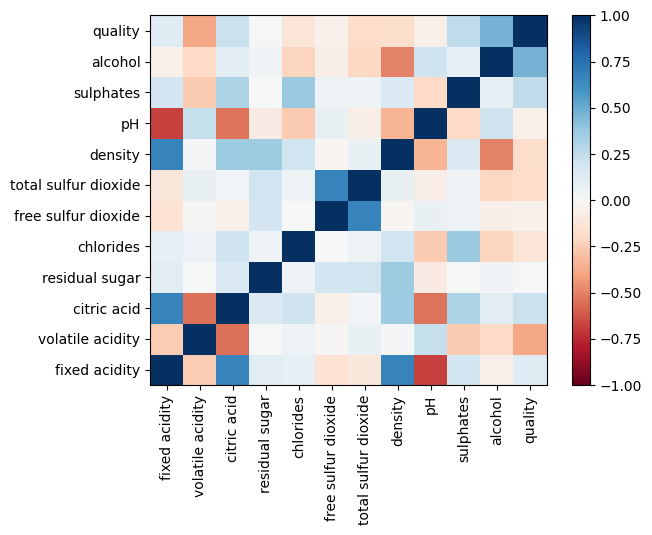

In [14]:
# Plot the correlation matrix with colors showing the value
import matplotlib.pyplot as plt
import numpy as np

plt.pcolor(df.corr(), cmap='RdBu', vmin=-1, vmax=1)
# plt.xticks(plt.xticks()[0], df.columns)
plt.yticks(np.arange(len(df.columns)) + 0.5, df.columns)
plt.xticks(np.arange(len(df.columns)) + 0.5, df.columns, rotation=90)
plt.colorbar()

There are several ways to analyse and summarize the correlation. Using a pcolor map helps me quickly identify the highly correlation (darkee blue) attributes like total sulfur dioxide and free sulfur dioxide, and density with fixed acidity, and the highly negatively correlated attributes (deep red) like pH and fixed acidity. It also shows that attributes like chlorides and free sulfur dioxide are not correlated at all.

Note that I used vmin = -1 and vmax = 1 to ensure that the range of colors is between -1 and 1, otherwise depending on the dataset, the deep colors may not have the same meaning.

Another way to analyse this would be to just show where the correlation values are greated than 0.5
***

In [15]:
df.corr() > 0.5

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,True,False,True,False,False,False,False,True,False,False,False,False
volatile acidity,False,True,False,False,False,False,False,False,False,False,False,False
citric acid,True,False,True,False,False,False,False,False,False,False,False,False
residual sugar,False,False,False,True,False,False,False,False,False,False,False,False
chlorides,False,False,False,False,True,False,False,False,False,False,False,False
free sulfur dioxide,False,False,False,False,False,True,True,False,False,False,False,False
total sulfur dioxide,False,False,False,False,False,True,True,False,False,False,False,False
density,True,False,False,False,False,False,False,True,False,False,False,False
pH,False,False,False,False,False,False,False,False,True,False,False,False
sulphates,False,False,False,False,False,False,False,False,False,True,False,False


3. (10pts) Create a scatter plot for the attributes *residual sugar* and *pH* and interpret the plot.

In [16]:
# Seaborn package has some nicer plots
import seaborn as sns

<Axes: xlabel='residual sugar', ylabel='pH'>

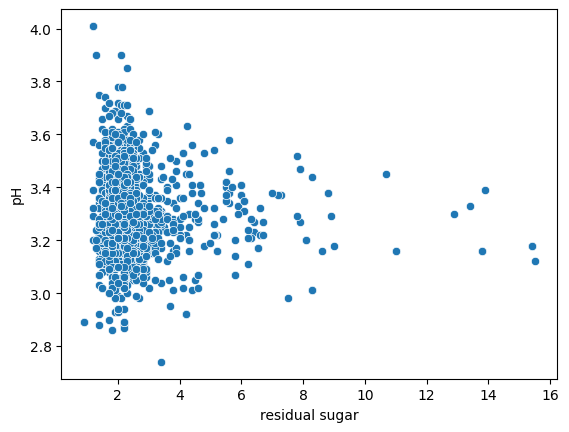

In [17]:
# Plot a scatter plot between residual sugar and pH using seaborn
sns.scatterplot(data=df, x='residual sugar', y='pH')

This plot shows that there is very mild correlation or almost none between pH and residual sugar. There is a concentration of points at the lower residual sugar levels, showing that only few wine samples have higher residual sugar concentrations. There areclearly some outliers in residual sugar. There are also few outliers in pH showing that one or two wine samples have less acidity
***

4. (10pts) Create a scatter plot for the attributes *fixed acidity* and *citric acid* and interpret the plot.

<Axes: xlabel='fixed acidity', ylabel='citric acid'>

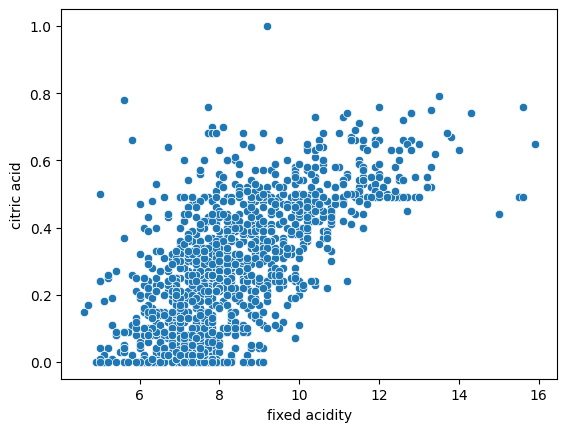

In [18]:
sns.scatterplot(data=df, x='fixed acidity', y='citric acid')

This plot shows a strong positive correlation between fixed acidity and citric acid attributes. There are some outliers. There also seem to be several samples where the value of citric acid is zero, and might be worth investigating to see if there are any problems with those samples
***

5. (15pts) Create histogram of the *quality* attribute and interpret the resulting histogram.

array([[<Axes: title={'center': 'quality'}>]], dtype=object)

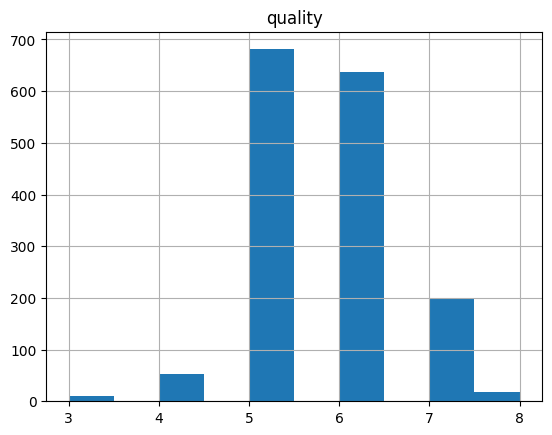

In [19]:
# Pandas offers a histogram method
df.hist('quality')

The quality attribute ranges from 3 to 8, with very few values equal to 3 and 8. Mode (peak) of the data is 5. This distribution is unimodal (only one peak).


In [22]:
# Compute mean and median of 'quality' attribute
print(f"Mean of quality is : {df['quality'].mean()}")
print(f"Median of quality is : {df['quality'].median()}")


Mean of quality is : 5.6360225140712945
Median of quality is : 6.0


Since the mean is slightly smaller than the median, the data is more or less symmetric but has a slight left skew.

Seaborn does a better histogram

<Axes: xlabel='quality', ylabel='Count'>

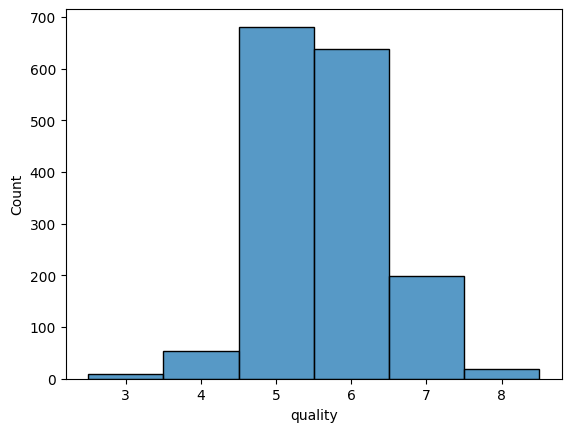

In [23]:
sns.histplot(data=df, x='quality', discrete=True)

6. (25pts) Create box plots for *alcohol* and *pH* attributes for the instances of the
3 *quality* class (Bad, Good, and Very Good), and a box plot for all instances in the dataset.  Interpret the resulting box plots. Compare the two box plots

For simplicity, we create a new column 'quality_class' and categorize the 'quality' column into 'Bad', 'Good', and 'Very Good', then create separate dataframes for each category.



In [24]:
df['quality_class'] = df['quality'].apply(lambda x: 'Bad' if x <= 4 else ('Good' if x <= 6 else 'Very Good'))

df_bad = df[df['quality_class'] == 'Bad']
df_good = df[df['quality_class'] == 'Good']
df_very_good = df[df['quality_class'] == 'Very Good']

Set up a figure with four subplots to hold the box plots


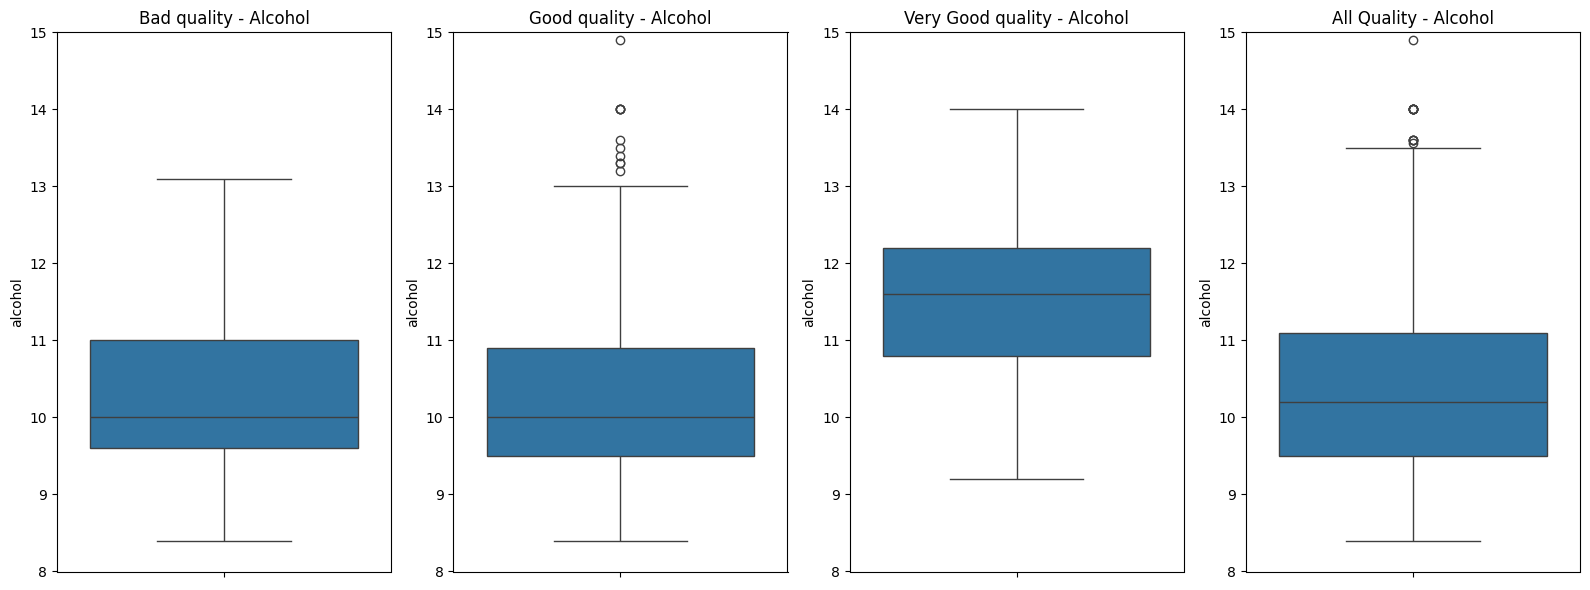

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 6)) # Changed to 1 row and 4 columns
sns.boxplot(data=df_bad, y='alcohol', ax=axes[0]).set_title('Bad quality - Alcohol') # Accessing axes with a single index
axes[0].set_ylim(8, 15)
sns.boxplot(data=df_good, y='alcohol', ax=axes[1]).set_title("Good quality - Alcohol") # Accessing axes with a single index
axes[1].set_ylim(8, 15)
sns.boxplot(data=df_very_good, y='alcohol', ax=axes[2]).set_title("Very Good quality - Alcohol") # Accessing axes with a single index
axes[2].set_ylim(8, 15)
sns.boxplot(data=df, y='alcohol', ax=axes[3]).set_title("All Quality - Alcohol") # Accessing axes with a single index
axes[3].set_ylim(8, 15)
plt.tight_layout()
plt.show()

Note that it is easier to compare box plots if we plot using the same axes. In general quality seems to go up with alcohol amount. There are more outliers in the good quality data. Ranges are similar, that is the variation in the data is similar for each of the quality labels, which tells us that we do not have data with a class imbalance.

Repeat for pH

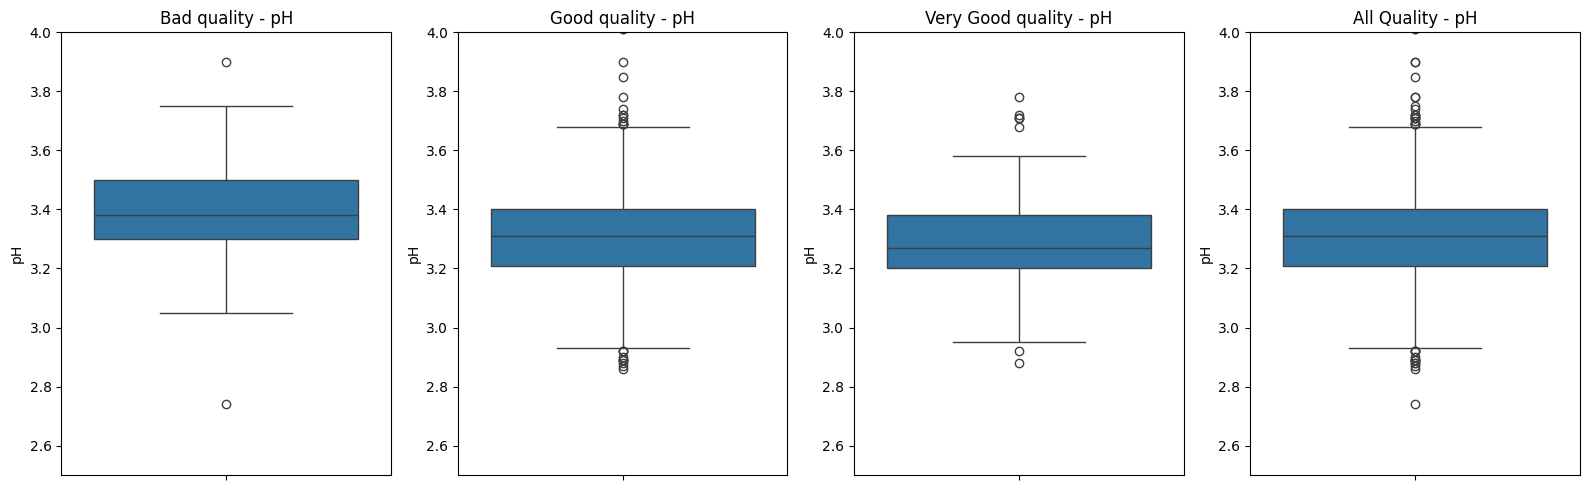

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
sns.boxplot(data=df_bad, y='pH', ax=axes[0]).set_title('Bad quality - pH')
axes[0].set_ylim(2.5, 4)
sns.boxplot(data=df_good, y='pH', ax=axes[1]).set_title("Good quality - pH")
axes[1].set_ylim(2.5, 4)
sns.boxplot(data=df_very_good, y='pH', ax=axes[2]).set_title("Very Good quality - pH")
axes[2].set_ylim(2.5, 4)
sns.boxplot(data=df, y='pH', ax=axes[3]).set_title("All Quality - pH")
axes[3].set_ylim(2.5, 4)

plt.tight_layout()
plt.show()

When the data is sorted into different classes, there are more outliers. This could mean that the range for each class is very wide and not informative in determining the class. The medians are also almost the same for the three classes, although median of combined dataset is slightly higher (accounting for all the outliers).  

Now let's compare the alcohol and pH box plots for all the data. We want to look at


*   Median
*   IQR and overlap
*   Whisker interval overlap
*   Skewness
*   Outliers

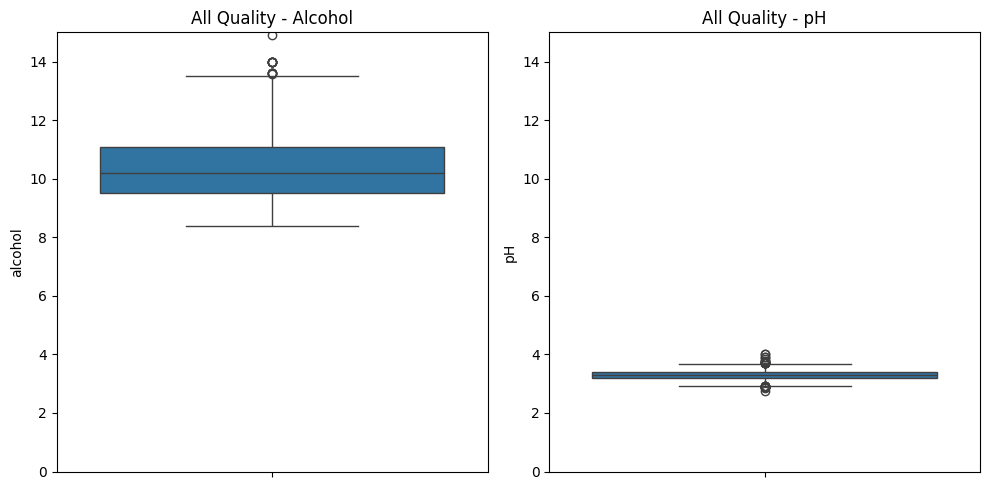

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(data=df, y='alcohol', ax=axes[0]).set_title("All Quality - Alcohol")
axes[0].set_ylim(0, 15)
sns.boxplot(data=df, y='pH', ax=axes[1]).set_title("All Quality - pH")
axes[1].set_ylim(0, 15)

plt.tight_layout()
plt.show()

* Median: Median of alcohol is higher than median of pH. In fact, the values are so different that we may want to normalize to compare them (not expected in the homework)
* IQR and overlap: There is more spread in the values for alcohol as compared the values of pH. There is no overlap between the values making them dissimilar
* Whisker interval overlap: Even the whisker intervals do not overlap
* Skewness:Alcohol looks more or less symmetric, maybe slightly right skewed. pH is quite symmetric
* Outliers: pH has a lot of outliers compared to alcohol.

As a final summary, these two attributes do not seem to have much in common. This is also shown by the correlation between them not being very high.

Let's now plot them after scaling

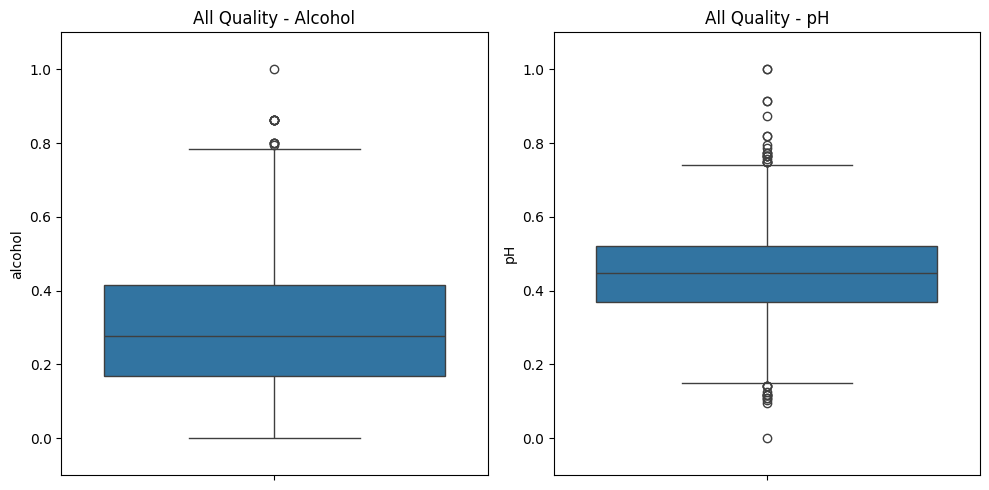

In [28]:
#Scale alcohol and ph values before plotting the box plot
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['alcohol', 'pH']] = scaler.fit_transform(df[['alcohol', 'pH']])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(data=df_scaled, y='alcohol', ax=axes[0]).set_title("All Quality - Alcohol")
axes[0].set_ylim(-0.1, 1.1)
sns.boxplot(data=df_scaled, y='pH', ax=axes[1]).set_title("All Quality - pH")
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

Now we can clearly see the right skewness of alcohol as compared to the symmetric pH distribution.

There are still a lot more outliers in pH, but there is some overlap in the whisker interval. However, the overlap in IQR is still very minimal, meaning they are dissimilar attributes. In the normailized space also, range of pH is significantly smaller than range of alcohol. Alcohol content is more widely spread. Median here is not as meaningful since we have normalized the attribute values, other than to look at skewness.
***

7. (15pts) Write a brief conclusion summarizing the most important findings of this task; in particular, address the findings obtained related to predicting the quality of red wine.

While this assignment doesn't expect any plots, some plots are useful to illustrate the points

In [29]:
# Drop the 'quality_class' column before computing correlations
df_numeric = df.drop('quality_class', axis=1)
df_numeric.corr()["quality"]

,quality
fixed acidity,0.124052
volatile acidity,-0.390558
citric acid,0.226373
residual sugar,0.013732
chlorides,-0.128907
free sulfur dioxide,-0.050656
total sulfur dioxide,-0.185100
density,-0.174919
pH,-0.057731
sulphates,0.251397


In [30]:
df["quality"]

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [31]:
# Select all columns except 'quality_class' (since quality_class is not numeric, including this will throw an error)
df_subset = df.drop('quality_class', axis=1)
display(df_subset.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [32]:
# Look at correlation of all other attributes to quality
df_subset.corr()["quality"]

,quality
fixed acidity,0.124052
volatile acidity,-0.390558
citric acid,0.226373
residual sugar,0.013732
chlorides,-0.128907
free sulfur dioxide,-0.050656
total sulfur dioxide,-0.185100
density,-0.174919
pH,-0.057731
sulphates,0.251397


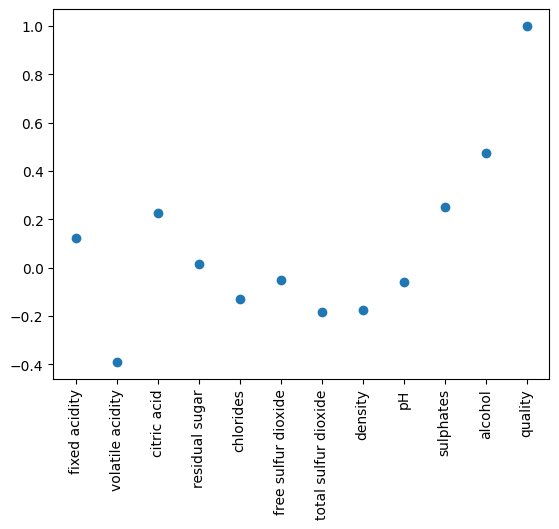

In [33]:
plt.plot(df_subset.corr()["quality"],marker='o', linestyle='None')
plt.xticks(rotation=90)
plt.show()

From the correlation of all other attributes to quality, we see that none of them in particular are correlated to quality. Alcohol seems to have a marginally strong positive correlation, while volatile acidity has a marginallys strong negative correlation. All other correlations are weak. So if we are trying to directly predict quality from these attributes, we may not be very successful. Note that we are not saying that we cannot preidict quality from the dataset, only that we cannot use just one of these attributes to predict quality. There may be a combination that can predict, this analysis does not show that. Scatter plots show a similar story



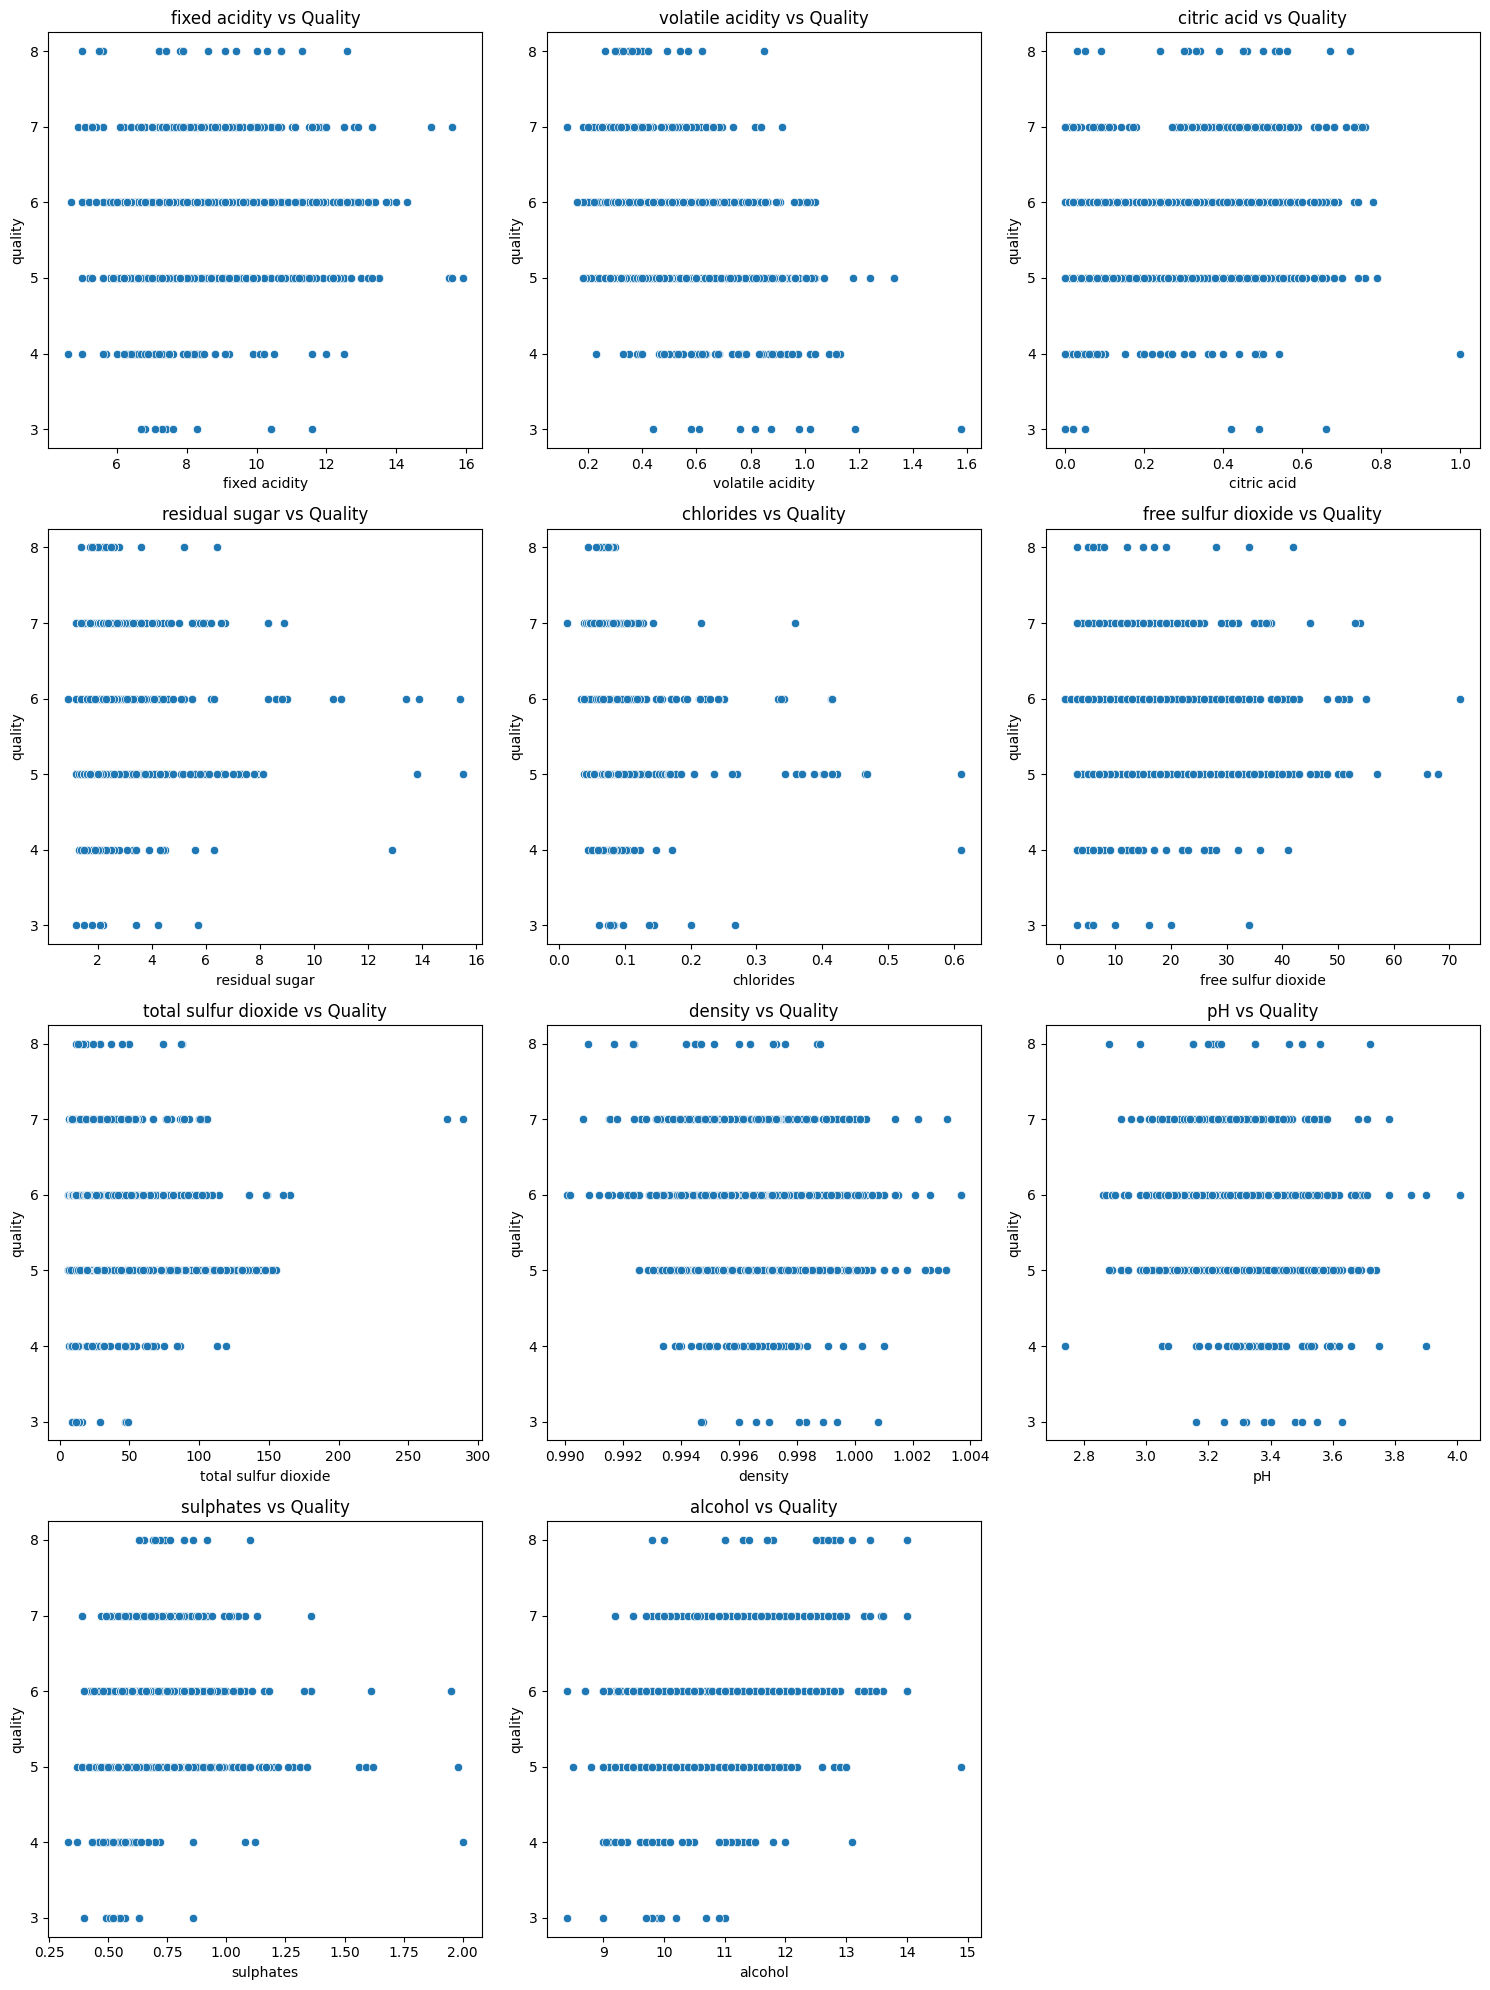

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of columns, excluding 'quality'
columns_to_plot = df.drop(columns=['quality', 'quality_class']).columns

# Determine the number of rows and columns for the subplots
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot scatter plot for each attribute against quality
for i, col in enumerate(columns_to_plot):
    sns.scatterplot(data=df, x=col, y='quality', ax=axes[i])
    axes[i].set_title(f'{col} vs Quality')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Now let us consider that we are more interested in the three quality ranges (bad, good, very good) rather than the 7 quality values. We can use the quality class and box plots to understand this.

In [36]:
# Let us remove quality and quality_class from the list of attributes
# It doesn't make sense to use the "labels" in box plots
attributes_to_plot = df.columns.tolist()
attributes_to_plot.remove('quality')
attributes_to_plot.remove('quality_class')
print(attributes_to_plot)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [37]:
n_rows = len(attributes_to_plot)
n_cols = df['quality_class'].nunique()

print(f"Number of rows needed: {n_rows}")
print(f"Number of columns needed: {n_cols}")

Number of rows needed: 11
Number of columns needed: 3


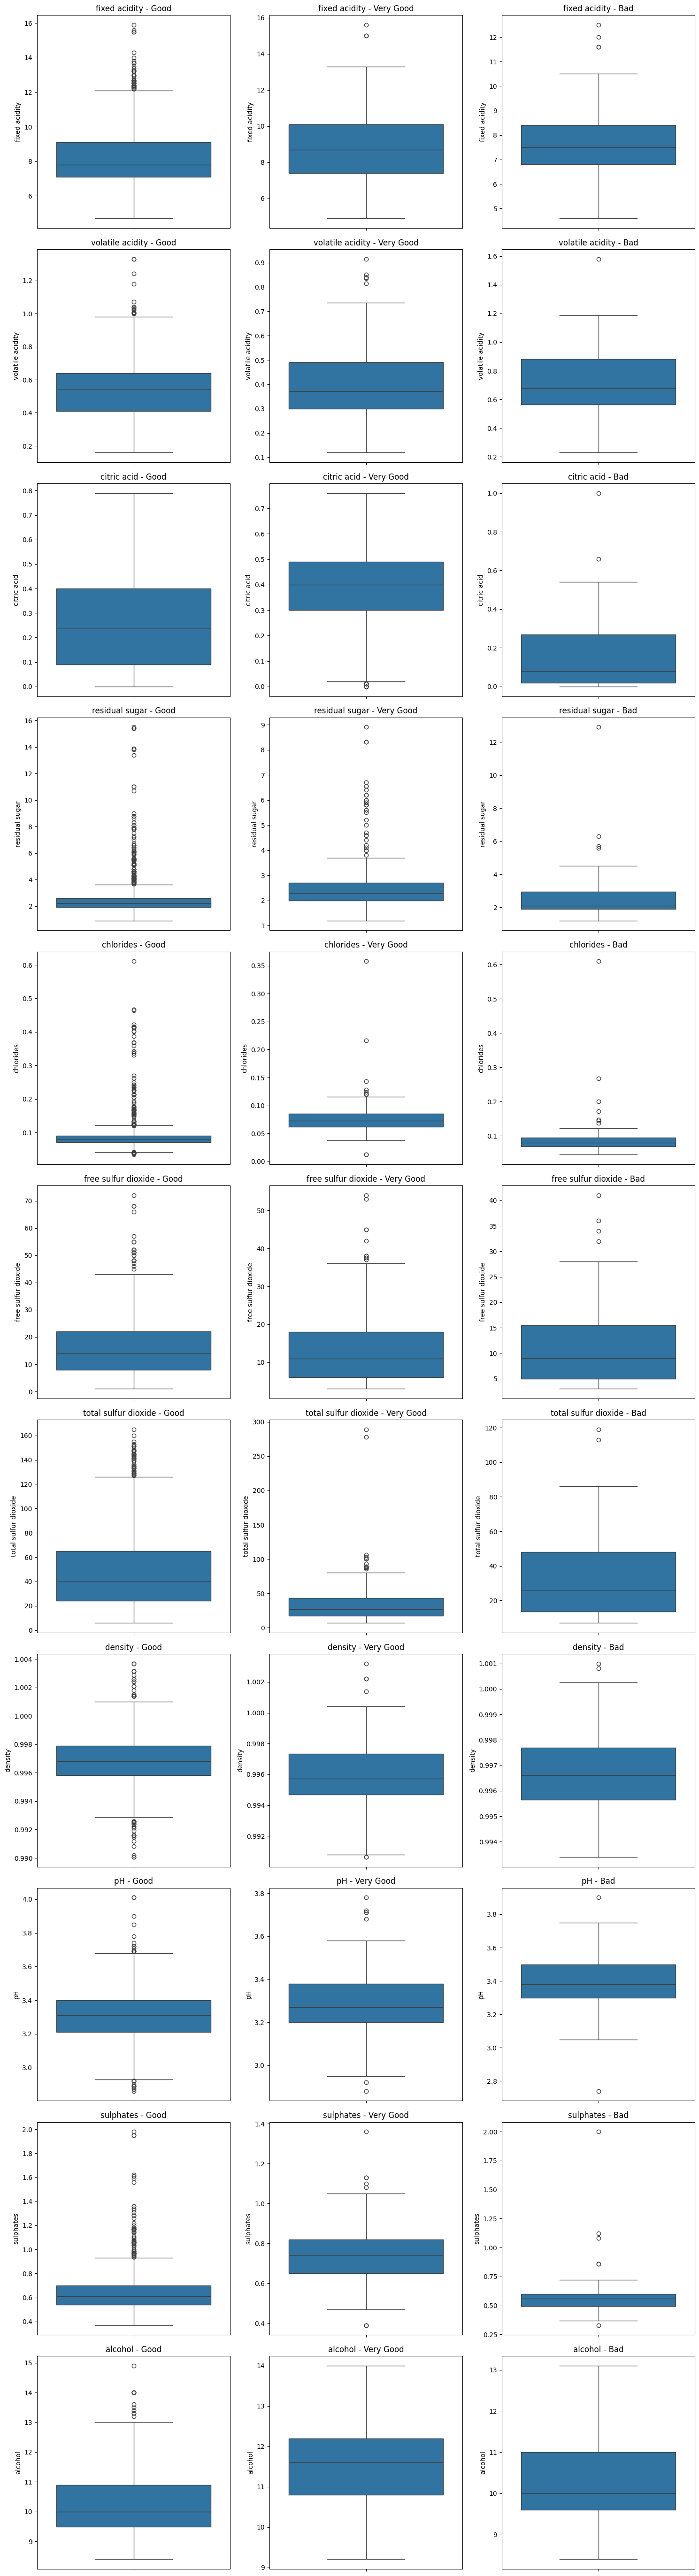

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

quality_classes = df['quality_class'].unique()

for i, attribute in enumerate(attributes_to_plot):
    for j, quality_class in enumerate(quality_classes):
        df_filtered = df[df['quality_class'] == quality_class]
        sns.boxplot(data=df_filtered, y=attribute, ax=axes[i * n_cols + j])
        axes[i * n_cols + j].set_title(f'{attribute} - {quality_class}')
        axes[i * n_cols + j].set_ylabel(attribute)

plt.tight_layout()
plt.show()

Looking at each row, it is immediately obvious that the only attributes which might help predict the quality class are fixed acitity, volatile acidity and pH. We notice that the overlap is pretty high between the box plots in each row, which means that it is difficult to separate the quality_class samples using only one of these attributes. Let's make some scatter plots


<Figure size 800x600 with 0 Axes>

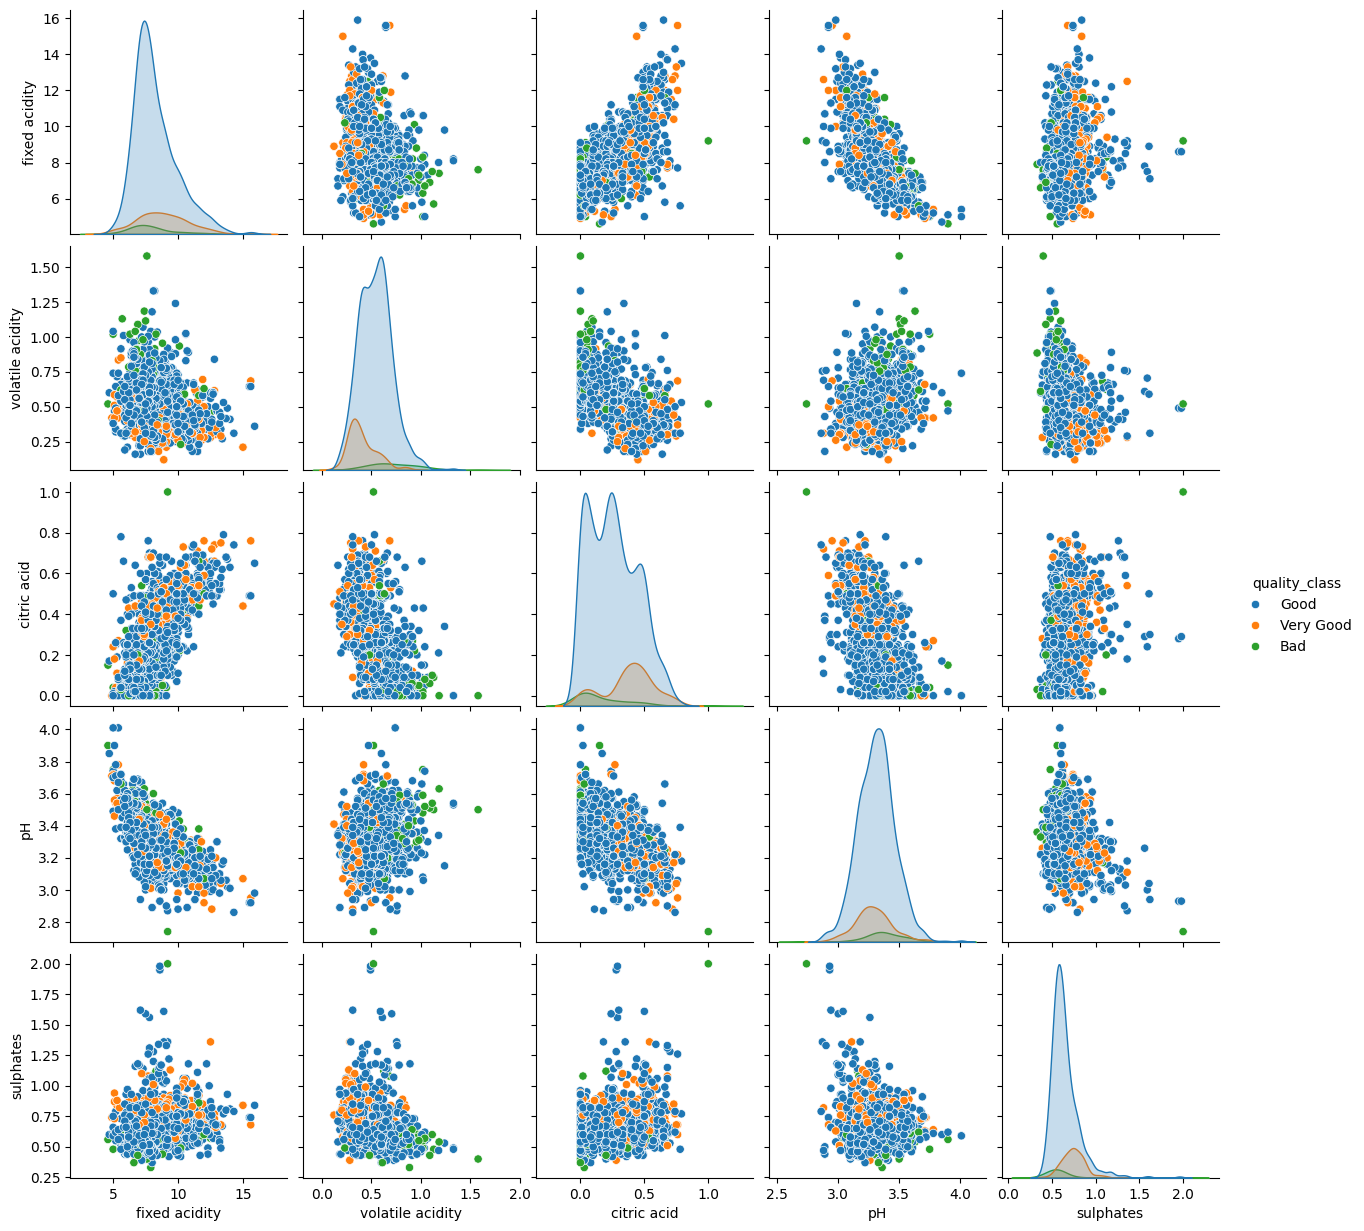

In [ ]:
plt.figure(figsize=(8, 6))
sns.pairplot(data=df[['fixed acidity','volatile acidity','citric acid','pH','sulphates','quality_class']], hue='quality_class')
